<a href="https://colab.research.google.com/github/idoyeon156-cloud/sampled_reachability_maps/blob/main/reachability_map_1%EC%B0%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ============================================================
# FR3 랜덤 관절각 샘플 생성
#
# 작업 순서:
# 1. CPU/GPU 계산 장치 선택
# 2. FR3의 7개 관절 한계 설정
# 3. 랜덤 seed 설정
# 4. 관절 한계 내에서 랜덤 샘플 생성
# 5. 생성 결과 검사
# 6. PyTorch 파일(.pt)로 저장
# ============================================================

import os
import torch


# ------------------------------------------------------------
# 1. 계산 장치(device)와 숫자 형식(dtype) 설정
# ------------------------------------------------------------

# CUDA를 사용할 수 있으면 NVIDIA GPU를 사용하고,
# 사용할 수 없으면 CPU를 사용합니다.
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# 관절각은 32비트 부동소수점으로 계산합니다.
# float32는 GPU 계산에 적합하고 메모리 사용량도 비교적 적습니다.
dtype = torch.float32

print("=" * 60)
print("1. PyTorch 실행 환경")
print("=" * 60)
print("PyTorch 버전:", torch.__version__)
print("사용 장치:", device)
print("숫자 형식:", dtype)

if torch.cuda.is_available():
    print("GPU 이름:", torch.cuda.get_device_name(0))
else:
    print("주의: CUDA GPU가 활성화되지 않았습니다.")
    print("Colab 메뉴에서 런타임 → 런타임 유형 변경 → T4 GPU를 선택하세요.")


# ------------------------------------------------------------
# 2. FR3 관절각 범위 설정
# ------------------------------------------------------------

# FR3에는 7개의 회전 관절이 있습니다.
# 아래 값의 단위는 degree가 아니라 radian입니다.
#
# q_min: 각 관절의 최소 허용 각도
# q_max: 각 관절의 최대 허용 각도

q_min = torch.tensor(
    [
        -2.9007,  # joint 1
        -1.8361,  # joint 2
        -2.9007,  # joint 3
        -3.0770,  # joint 4
        -2.8763,  # joint 5
         0.4398,  # joint 6
        -3.0508,  # joint 7
    ],
    dtype=dtype,
    device=device,
)

q_max = torch.tensor(
    [
         2.9007,  # joint 1
         1.8361,  # joint 2
         2.9007,  # joint 3
        -0.1169,  # joint 4
         2.8763,  # joint 5
         4.6216,  # joint 6
         3.0508,  # joint 7
    ],
    dtype=dtype,
    device=device,
)

print()
print("=" * 60)
print("2. FR3 관절 한계")
print("=" * 60)

for joint_index in range(7):
    print(
        f"joint {joint_index + 1}: "
        f"{q_min[joint_index].item():8.4f} ~ "
        f"{q_max[joint_index].item():8.4f} rad"
    )

print("q_min shape:", q_min.shape)
print("q_max shape:", q_max.shape)


# ------------------------------------------------------------
# 3. 랜덤 seed 설정
# ------------------------------------------------------------

# 같은 seed를 사용하면 같은 랜덤 샘플을 재현할 수 있습니다.
seed = 42

torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print()
print("=" * 60)
print("3. 랜덤 설정")
print("=" * 60)
print("Random seed:", seed)


# ------------------------------------------------------------
# 4. FR3 관절 샘플 생성
# ------------------------------------------------------------

# 처음에는 10만 개로 생성 과정을 확인합니다.
# 이후 1_000_000 등으로 늘릴 수 있습니다.
num_samples = 100_000

# 각 관절의 q_min ~ q_max 범위를 갖는 균등분포를 만듭니다.
joint_distribution = torch.distributions.Uniform(
    low=q_min,
    high=q_max,
)

# shape이 (num_samples, 7)인 관절각 샘플을 생성합니다.
#
# 각 행: FR3 자세 하나
# 각 열: joint 1 ~ joint 7의 각도
q_samples = joint_distribution.sample(
    (num_samples,)
)

print()
print("=" * 60)
print("4. 관절각 샘플 생성")
print("=" * 60)
print("샘플 개수:", num_samples)
print("샘플 shape:", q_samples.shape)
print("샘플 device:", q_samples.device)
print("샘플 dtype:", q_samples.dtype)


# ------------------------------------------------------------
# 5. 생성된 샘플 검사
# ------------------------------------------------------------

# 예상 shape인지 검사합니다.
assert q_samples.shape == (num_samples, 7)

# 모든 관절각이 q_min 이상인지 검사합니다.
assert torch.all(q_samples >= q_min)

# 모든 관절각이 q_max 이하인지 검사합니다.
assert torch.all(q_samples <= q_max)

print()
print("=" * 60)
print("5. 샘플 검사")
print("=" * 60)
print("Shape 검사: 통과")
print("관절 하한 검사: 통과")
print("관절 상한 검사: 통과")


# ------------------------------------------------------------
# 6. 일부 샘플 확인
# ------------------------------------------------------------

# 첫 5개의 관절 자세를 출력합니다.
print()
print("=" * 60)
print("6. 생성된 샘플 일부")
print("=" * 60)

print("\n첫 5개 샘플 — radian:")
print(q_samples[:5])

print("\n첫 5개 샘플 — degree:")
print(torch.rad2deg(q_samples[:5]))


# ------------------------------------------------------------
# 7. 관절별 통계 확인
# ------------------------------------------------------------

# dim=0으로 계산하면 각 관절 열에 대한 통계가 계산됩니다.
sampled_min = q_samples.min(dim=0).values
sampled_max = q_samples.max(dim=0).values
sampled_mean = q_samples.mean(dim=0)
sampled_std = q_samples.std(dim=0)

print()
print("=" * 60)
print("7. 관절별 샘플 통계")
print("=" * 60)

for joint_index in range(7):
    print(
        f"joint {joint_index + 1}: "
        f"min={sampled_min[joint_index].item():8.4f}, "
        f"max={sampled_max[joint_index].item():8.4f}, "
        f"mean={sampled_mean[joint_index].item():8.4f}, "
        f"std={sampled_std[joint_index].item():8.4f}"
    )


# ------------------------------------------------------------
# 8. 생성된 샘플 저장
# ------------------------------------------------------------

# GPU Tensor를 CPU Tensor로 옮겨 저장합니다.
# 이렇게 저장하면 GPU가 없는 환경에서도 파일을 불러올 수 있습니다.
save_data = {
    "q_samples": q_samples.cpu(),
    "q_min": q_min.cpu(),
    "q_max": q_max.cpu(),
    "num_samples": num_samples,
    "seed": seed,
    "robot": "fr3",
    "unit": "radian",
    "dtype": str(dtype),
}

file_name = "fr3_joint_samples_100k.pt"

torch.save(
    save_data,
    file_name,
)

file_size_mb = os.path.getsize(file_name) / (1024 ** 2)

print()
print("=" * 60)
print("8. 파일 저장")
print("=" * 60)
print("저장 파일:", file_name)
print(f"파일 크기: {file_size_mb:.2f} MB")


# ------------------------------------------------------------
# 9. 저장된 파일을 다시 불러와 확인
# ------------------------------------------------------------

loaded_data = torch.load(
    file_name,
    map_location="cpu",
    weights_only=False,
)

loaded_samples = loaded_data["q_samples"]

assert loaded_samples.shape == (num_samples, 7)
assert torch.equal(loaded_samples, q_samples.cpu())

print()
print("=" * 60)
print("9. 저장 파일 검증")
print("=" * 60)
print("저장된 robot:", loaded_data["robot"])
print("저장된 unit:", loaded_data["unit"])
print("저장된 seed:", loaded_data["seed"])
print("불러온 shape:", loaded_samples.shape)
print("원본과 저장 파일 비교: 일치")
print()
print("FR3 관절 샘플 생성이 완료되었습니다.")

1. PyTorch 실행 환경
PyTorch 버전: 2.11.0+cu128
사용 장치: cuda
숫자 형식: torch.float32
GPU 이름: Tesla T4

2. FR3 관절 한계
joint 1:  -2.9007 ~   2.9007 rad
joint 2:  -1.8361 ~   1.8361 rad
joint 3:  -2.9007 ~   2.9007 rad
joint 4:  -3.0770 ~  -0.1169 rad
joint 5:  -2.8763 ~   2.8763 rad
joint 6:   0.4398 ~   4.6216 rad
joint 7:  -3.0508 ~   3.0508 rad
q_min shape: torch.Size([7])
q_max shape: torch.Size([7])

3. 랜덤 설정
Random seed: 42

4. 관절각 샘플 생성
샘플 개수: 100000
샘플 shape: torch.Size([100000, 7])
샘플 device: cuda:0
샘플 dtype: torch.float32

5. 샘플 검사
Shape 검사: 통과
관절 하한 검사: 통과
관절 상한 검사: 통과

6. 생성된 샘플 일부

첫 5개 샘플 — radian:
tensor([[ 0.6553, -1.7992, -0.5893, -2.9577, -1.9774,  2.4574,  1.4415],
        [-0.5454,  0.0694, -1.2374, -2.3619,  2.4324,  3.9103, -2.8422],
        [-0.6504, -1.5335,  1.5906, -2.2505,  0.0796,  1.3047, -3.0058],
        [ 2.1757,  1.7194, -2.2039, -2.4933, -0.2862,  0.6536, -0.0658],
        [ 2.5126, -0.4379, -2.6057, -2.2889,  0.8598,  1.5584, -1.9934]],
       device='cuda:0')

첫 

In [5]:
# PyTorch 기반 로봇 기구학 계산 라이브러리
# FR3 URDF를 편하게 가져오는 라이브러리
!pip -q install pytorch-kinematics robot-descriptions

print("설치 완료")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.8/138.8 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.2/217.2 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.1/41.1 kB 3.2 MB/s eta 0:00:00
설치 완료


In [10]:
!pip -q install xacrodoc yourdfpy

print("xacrodoc 설치 완료")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 8.1 MB/s eta 0:00:00
xacrodoc 설치 완료


In [11]:
from robot_descriptions.loaders.yourdfpy import load_robot_description

# Xacro 템플릿을 처리해 FR3 모델을 불러옵니다.
fr3_robot = load_robot_description("fr3_description")

# 완성된 URDF 파일로 저장합니다.
urdf_path = "/content/fr3.urdf"
fr3_robot.write_xml_file(urdf_path)

# pytorch-kinematics에 전달할 문자열로 읽습니다.
with open(urdf_path, "r") as file:
    urdf_text = file.read()

print("FR3 URDF 생성 완료")
print("저장 경로:", urdf_path)
print("URDF 글자 수:", len(urdf_text))
print()
print(urdf_text[:200])

FR3 URDF 생성 완료
저장 경로: /content/fr3.urdf
URDF 글자 수: 17007

<?xml version='1.0' encoding='ASCII'?>
<robot name="fr3">
  <link name="base"/>
  <link name="fr3_link0">
    <inertial>
      <origin xyz="-0.0172 0.0004 0.0745" rpy="0.0 -0.0 0.0"/>
      <mass valu


In [12]:
import xml.etree.ElementTree as ET

urdf_root = ET.fromstring(urdf_text)

link_names = [
    link.attrib["name"]
    for link in urdf_root.findall("link")
]

print("전체 링크 수:", len(link_names))

for link_name in link_names:
    print(link_name)

전체 링크 수: 26
base
fr3_link0
fr3_link0_accelerometer_top
fr3_link0_accelerometer_bottom
fr3_link1
fr3_link1_accelerometer_top
fr3_link1_accelerometer_bottom
fr3_link2
fr3_link2_accelerometer_top
fr3_link2_accelerometer_bottom
fr3_link3
fr3_link3_accelerometer_top
fr3_link3_accelerometer_bottom
fr3_link4
fr3_link4_accelerometer_top
fr3_link4_accelerometer_bottom
fr3_link5
fr3_link5_accelerometer_top
fr3_link5_accelerometer_bottom
fr3_link6
fr3_link7
fr3_link8
fr3_hand
fr3_hand_tcp
fr3_leftfinger
fr3_rightfinger


In [15]:
import pytorch_kinematics as pk

# "r"이 아니라 "rb"로 열어 bytes 형태로 읽습니다.
with open(urdf_path, "rb") as file:
    urdf_bytes = file.read()

print("URDF 데이터 형식:", type(urdf_bytes))
print("URDF 크기:", len(urdf_bytes), "bytes")

# bytes 형태의 URDF로 기구학 체인을 생성합니다.
chain = pk.build_serial_chain_from_urdf(
    urdf_bytes,
    end_effector_link,
)

chain = chain.to(
    device=device,
    dtype=dtype,
)

joint_names = chain.get_joint_parameter_names()

print("\n기구학 체인에 포함된 관절:")

for joint_index, joint_name in enumerate(joint_names):
    print(f"{joint_index + 1}: {joint_name}")

print("\n관절 개수:", len(joint_names))

assert len(joint_names) == 7

print("관절 개수 검사 통과")

# 앞에서 생성한 관절 샘플 중 처음 10개
q_test = q_samples[:10].to(
    device=device,
    dtype=dtype,
)

# Forward Kinematics
fk_result = chain.forward_kinematics(q_test)

# 4×4 transformation matrix
transform_matrices = fk_result.get_matrix()

# 엔드이펙터 위치 [x, y, z]
positions = transform_matrices[:, :3, 3]

print("입력 shape:", q_test.shape)
print("FK 결과 shape:", transform_matrices.shape)
print("위치 shape:", positions.shape)

print("\n엔드이펙터 위치 10개, 단위 meter:")
print(positions)


URDF 데이터 형식: <class 'bytes'>
URDF 크기: 17007 bytes

기구학 체인에 포함된 관절:
1: fr3_joint1
2: fr3_joint2
3: fr3_joint3
4: fr3_joint4
5: fr3_joint5
6: fr3_joint6
7: fr3_joint7

관절 개수: 7
관절 개수 검사 통과


Unknown attribute "name" in /robot[@name='fr3']/link[@name='fr3_link0']/visual[1]
Unknown attribute "name" in /robot[@name='fr3']/link[@name='fr3_link0']/collision[1]
Unknown attribute "name" in /robot[@name='fr3']/link[@name='fr3_link1']/visual[1]
Unknown attribute "name" in /robot[@name='fr3']/link[@name='fr3_link1']/collision[1]
Unknown attribute "name" in /robot[@name='fr3']/link[@name='fr3_link2']/visual[1]
Unknown attribute "name" in /robot[@name='fr3']/link[@name='fr3_link2']/collision[1]
Unknown attribute "name" in /robot[@name='fr3']/link[@name='fr3_link3']/visual[1]
Unknown attribute "name" in /robot[@name='fr3']/link[@name='fr3_link3']/collision[1]
Unknown attribute "name" in /robot[@name='fr3']/link[@name='fr3_link4']/visual[1]
Unknown attribute "name" in /robot[@name='fr3']/link[@name='fr3_link4']/collision[1]
Unknown attribute "name" in /robot[@name='fr3']/link[@name='fr3_link5']/visual[1]
Unknown attribute "name" in /robot[@name='fr3']/link[@name='fr3_link5']/collision[1

입력 shape: torch.Size([10, 7])
FK 결과 shape: torch.Size([10, 4, 4])
위치 shape: torch.Size([10, 3])

엔드이펙터 위치 10개, 단위 meter:
tensor([[ 0.2910, -0.0483,  0.6010],
        [-0.2139, -0.3219,  0.2590],
        [ 0.2332,  0.2170,  0.3068],
        [ 0.0473,  0.1008,  0.4660],
        [ 0.3808,  0.1456,  0.1907],
        [ 0.2249,  0.2534,  0.0990],
        [ 0.4527, -0.3777,  0.8271],
        [-0.7377, -0.3321,  0.3222],
        [ 0.3514, -0.2992,  0.8073],
        [-0.3356, -0.0222,  1.0494]], device='cuda:0')


In [16]:
# ============================================================
# FR3 관절 샘플 10만 개의 Forward Kinematics 계산
# ============================================================

import time
import torch


# 한 번에 GPU에서 계산할 샘플 수
batch_size = 10_000

# 전체 샘플 수
num_samples = q_samples.shape[0]

# batch별 위치 결과를 저장할 리스트
position_batches = []

print("전체 샘플 수:", num_samples)
print("Batch 크기:", batch_size)
print("계산 장치:", device)
print()

start_time = time.time()


# FK는 학습이 아니므로 gradient 계산을 끕니다.
# 이렇게 하면 메모리 사용량이 줄어듭니다.
with torch.no_grad():

    # 0부터 num_samples까지 batch_size 간격으로 반복합니다.
    for start_index in range(0, num_samples, batch_size):

        end_index = min(
            start_index + batch_size,
            num_samples,
        )

        # 현재 batch의 관절각
        q_batch = q_samples[start_index:end_index].to(
            device=device,
            dtype=dtype,
        )

        # Forward Kinematics 계산
        fk_batch = chain.forward_kinematics(q_batch)

        # 4×4 transformation matrix
        transform_batch = fk_batch.get_matrix()

        # 엔드이펙터 위치 [x, y, z]만 추출
        position_batch = transform_batch[:, :3, 3]

        # GPU 메모리를 계속 사용하지 않도록 CPU로 옮겨 저장
        position_batches.append(position_batch.cpu())

        print(
            f"진행: {end_index:>7,} / {num_samples:,}"
        )


# 나뉘어 있던 batch를 하나의 Tensor로 합칩니다.
positions_all = torch.cat(
    position_batches,
    dim=0,
)

elapsed_time = time.time() - start_time

print()
print("FK 계산 완료")
print("결과 shape:", positions_all.shape)
print(f"계산 시간: {elapsed_time:.2f}초")

전체 샘플 수: 100000
Batch 크기: 10000
계산 장치: cuda

진행:  10,000 / 100,000
진행:  20,000 / 100,000
진행:  30,000 / 100,000
진행:  40,000 / 100,000
진행:  50,000 / 100,000
진행:  60,000 / 100,000
진행:  70,000 / 100,000
진행:  80,000 / 100,000
진행:  90,000 / 100,000
진행: 100,000 / 100,000

FK 계산 완료
결과 shape: torch.Size([100000, 3])
계산 시간: 0.06초


In [17]:
# x, y, z 각각의 최솟값과 최댓값
position_min = positions_all.min(dim=0).values
position_max = positions_all.max(dim=0).values
position_mean = positions_all.mean(dim=0)

axis_names = ["x", "y", "z"]

print("FR3 엔드이펙터 위치 범위")
print()

for axis_index, axis_name in enumerate(axis_names):
    print(
        f"{axis_name}: "
        f"{position_min[axis_index].item():7.3f} ~ "
        f"{position_max[axis_index].item():7.3f} m "
        f"(평균: {position_mean[axis_index].item():7.3f} m)"
    )

FR3 엔드이펙터 위치 범위

x:  -0.941 ~   0.945 m (평균:   0.000 m)
y:  -0.941 ~   0.942 m (평균:  -0.000 m)
z:  -0.435 ~   1.275 m (평균:   0.523 m)


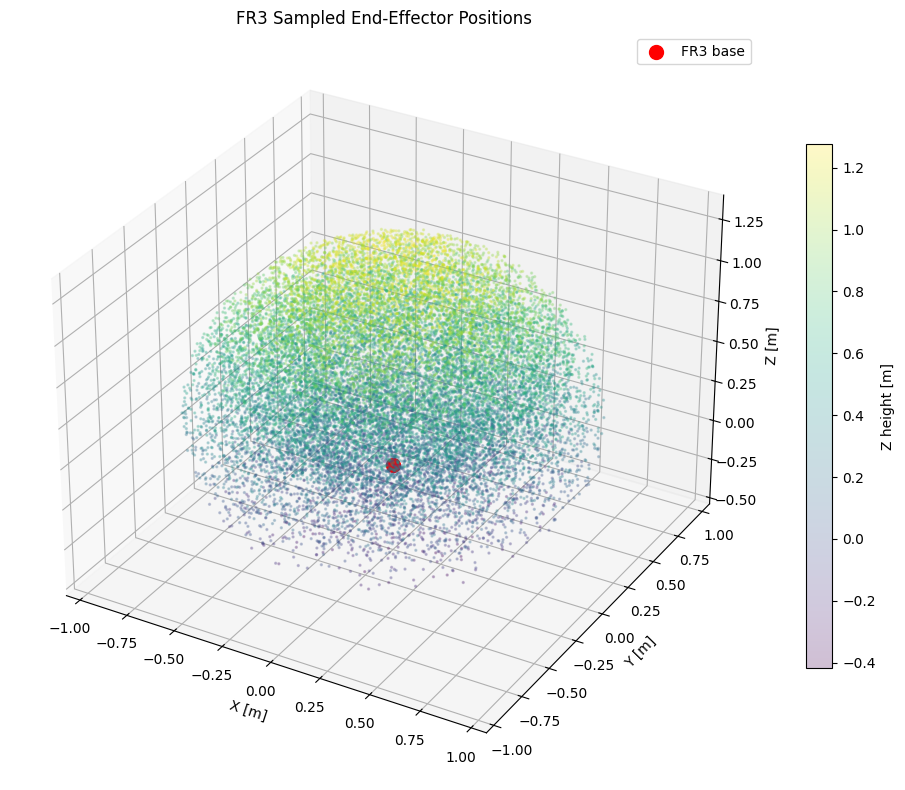

In [18]:
# ============================================================
# FR3 도달 가능 위치 3D 시각화
# ============================================================

import matplotlib.pyplot as plt


# 시각화에 사용할 점 개수
num_plot_points = min(
    20_000,
    positions_all.shape[0],
)

# 시각화할 샘플을 무작위로 선택
plot_indices = torch.randperm(
    positions_all.shape[0]
)[:num_plot_points]

plot_positions = positions_all[plot_indices].numpy()

x = plot_positions[:, 0]
y = plot_positions[:, 1]
z = plot_positions[:, 2]


# 3D 그래프 생성
fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(
    111,
    projection="3d",
)

# 점의 색상은 z 높이를 나타냅니다.
scatter = ax.scatter(
    x,
    y,
    z,
    c=z,
    cmap="viridis",
    s=2,
    alpha=0.25,
)

# FR3 base 위치를 빨간 점으로 표시
ax.scatter(
    0,
    0,
    0,
    color="red",
    s=100,
    label="FR3 base",
)

ax.set_title(
    "FR3 Sampled End-Effector Positions"
)

ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")
ax.set_zlabel("Z [m]")

ax.legend()

fig.colorbar(
    scatter,
    ax=ax,
    label="Z height [m]",
    shrink=0.7,
)

plt.tight_layout()
plt.show()

In [19]:
fk_file_name = "fr3_fk_positions_100k.pt"

torch.save(
    {
        "q_samples": q_samples.cpu(),
        "positions": positions_all,
        "end_effector_link": end_effector_link,
        "robot": "fr3",
        "unit_position": "meter",
        "unit_joint": "radian",
        "seed": seed,
    },
    fk_file_name,
)

print("저장 완료:", fk_file_name)

저장 완료: fr3_fk_positions_100k.pt


In [20]:
# ============================================================
# FR3 위치 기반 3D Reachability Map 생성
# ============================================================

import torch


# voxel 한 변의 길이
# 0.05 m = 5 cm
voxel_resolution = 0.05


# ------------------------------------------------------------
# 1. 연속적인 위치를 voxel 정수 좌표로 변환
# ------------------------------------------------------------

# 예:
# x = 0.123 m, resolution = 0.05 m
# 0.123 / 0.05 = 2.46
# floor(2.46) = voxel index 2
voxel_indices = torch.floor(
    positions_all / voxel_resolution
).to(torch.int64)

print("위치 shape:", positions_all.shape)
print("Voxel index shape:", voxel_indices.shape)

print("\n첫 번째 위치:")
print(positions_all[0])

print("첫 번째 위치의 voxel index:")
print(voxel_indices[0])


# ------------------------------------------------------------
# 2. 중복 voxel을 합치고 방문 횟수 계산
# ------------------------------------------------------------

# 같은 voxel에 들어간 위치들을 하나로 합칩니다.
# return_counts=True로 각 voxel의 방문 횟수도 계산합니다.
unique_voxel_indices, visitation_counts = torch.unique(
    voxel_indices,
    dim=0,
    return_counts=True,
)

print()
print("전체 FK 샘플 수:", positions_all.shape[0])
print("방문한 voxel 수:", unique_voxel_indices.shape[0])


# ------------------------------------------------------------
# 3. voxel index를 voxel 중심 위치로 변환
# ------------------------------------------------------------

# 각 voxel의 모서리가 아니라 중심 좌표를 사용합니다.
voxel_centers = (
    unique_voxel_indices.to(torch.float32) + 0.5
) * voxel_resolution

print("Voxel 중심 shape:", voxel_centers.shape)
print("방문 횟수 shape:", visitation_counts.shape)

print("\n첫 번째 voxel 중심:")
print(voxel_centers[0])

print("첫 번째 voxel 방문 횟수:")
print(visitation_counts[0])

위치 shape: torch.Size([100000, 3])
Voxel index shape: torch.Size([100000, 3])

첫 번째 위치:
tensor([ 0.2910, -0.0483,  0.6010])
첫 번째 위치의 voxel index:
tensor([ 5, -1, 12])

전체 FK 샘플 수: 100000
방문한 voxel 수: 24682
Voxel 중심 shape: torch.Size([24682, 3])
방문 횟수 shape: torch.Size([24682])

첫 번째 voxel 중심:
tensor([-0.9250, -0.2250,  0.2250])
첫 번째 voxel 방문 횟수:
tensor(2)


In [21]:
print("방문 횟수 통계")
print()

print(
    "최소 방문 횟수:",
    visitation_counts.min().item(),
)

print(
    "최대 방문 횟수:",
    visitation_counts.max().item(),
)

print(
    "평균 방문 횟수:",
    visitation_counts.float().mean().item(),
)

print(
    "한 번만 방문한 voxel 수:",
    torch.sum(visitation_counts == 1).item(),
)

print(
    "10번 이상 방문한 voxel 수:",
    torch.sum(visitation_counts >= 10).item(),
)

방문 횟수 통계

최소 방문 횟수: 1
최대 방문 횟수: 20
평균 방문 횟수: 4.051535606384277
한 번만 방문한 voxel 수: 4459
10번 이상 방문한 voxel 수: 928


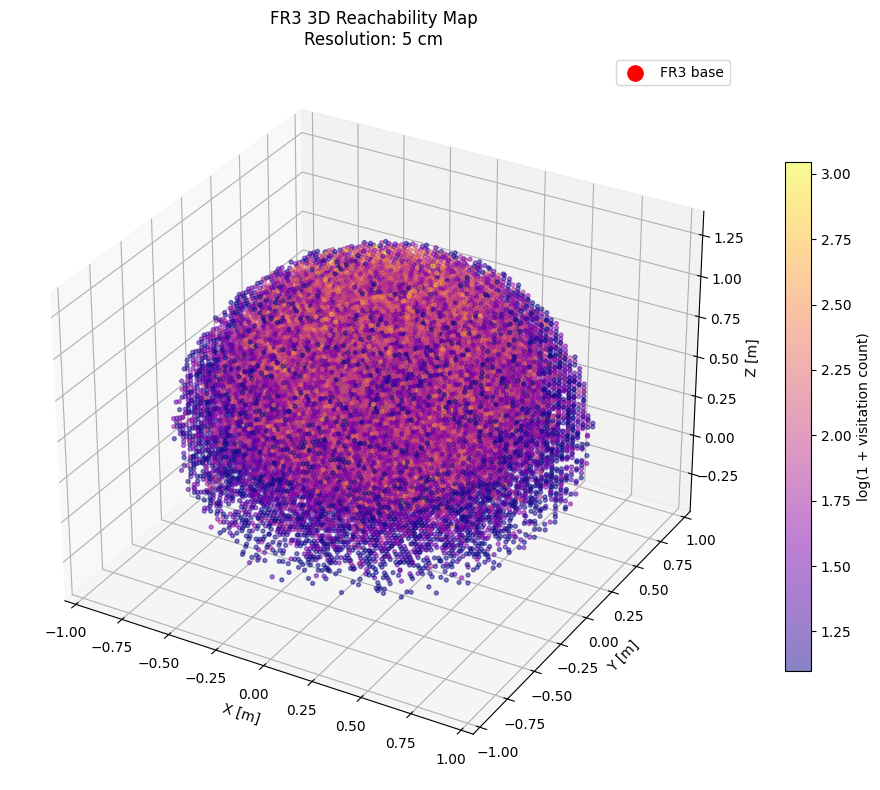

In [22]:
# ============================================================
# 3D Voxel Reachability Map 시각화
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# 너무 많은 voxel을 그리면 느려질 수 있으므로 제한합니다.
num_plot_voxels = min(
    20_000,
    voxel_centers.shape[0],
)

# 방문 횟수가 많은 voxel부터 선택
sorted_indices = torch.argsort(
    visitation_counts,
    descending=True,
)

plot_indices = sorted_indices[:num_plot_voxels]

plot_centers = voxel_centers[plot_indices].numpy()
plot_counts = visitation_counts[plot_indices].numpy()


# 방문 횟수 편차가 크므로 log 값을 색상으로 사용합니다.
plot_log_counts = np.log1p(plot_counts)

x = plot_centers[:, 0]
y = plot_centers[:, 1]
z = plot_centers[:, 2]


fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(
    111,
    projection="3d",
)

scatter = ax.scatter(
    x,
    y,
    z,
    c=plot_log_counts,
    cmap="plasma",
    s=8,
    alpha=0.5,
)

# FR3 base 원점
ax.scatter(
    0,
    0,
    0,
    color="red",
    s=120,
    label="FR3 base",
)

ax.set_title(
    "FR3 3D Reachability Map\n"
    f"Resolution: {voxel_resolution * 100:.0f} cm"
)

ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")
ax.set_zlabel("Z [m]")

ax.legend()

colorbar = fig.colorbar(
    scatter,
    ax=ax,
    shrink=0.7,
)

colorbar.set_label(
    "log(1 + visitation count)"
)

plt.tight_layout()
plt.show()

In [23]:
reachability_file_name = "fr3_reachability_3d_5cm_100k.pt"

torch.save(
    {
        "voxel_centers": voxel_centers,
        "voxel_indices": unique_voxel_indices,
        "visitation_counts": visitation_counts,
        "voxel_resolution": voxel_resolution,
        "num_joint_samples": positions_all.shape[0],
        "end_effector_link": end_effector_link,
        "robot": "fr3",
        "position_unit": "meter",
    },
    reachability_file_name,
)

print("3D reachability map 저장 완료")
print("파일:", reachability_file_name)
print("Voxel 개수:", voxel_centers.shape[0])

3D reachability map 저장 완료
파일: fr3_reachability_3d_5cm_100k.pt
Voxel 개수: 24682
